---
# CNN : `MNIST` (avec `Keras`)
---

## Packages

In [1]:
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from keras import callbacks, layers, models
from keras.datasets import mnist

---
## 1. Données
---

### 1.1. Importation

In [13]:
test_portion  = 1/5

(X_train_valid, y_train_valid), (X_test, y_test) = mnist.load_data()

X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, test_size=test_portion)

print('Dimensions de X_train :', X_train.shape)
print('Dimensions de X_valid :', X_valid.shape)
print('Dimensions de X_test  :', X_test.shape)

print('Dimensions de y_train :', y_train.shape)
print('Dimensions de y_valid :', y_valid.shape)
print('Dimensions de y_test  :', y_test.shape)

print(X_train_valid)

Dimensions de X_train : (48000, 28, 28)
Dimensions de X_valid : (12000, 28, 28)
Dimensions de X_test  : (10000, 28, 28)
Dimensions de y_train : (48000,)
Dimensions de y_valid : (12000,)
Dimensions de y_test  : (10000,)
[[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 ...

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]]


### 1.2. Graphiques

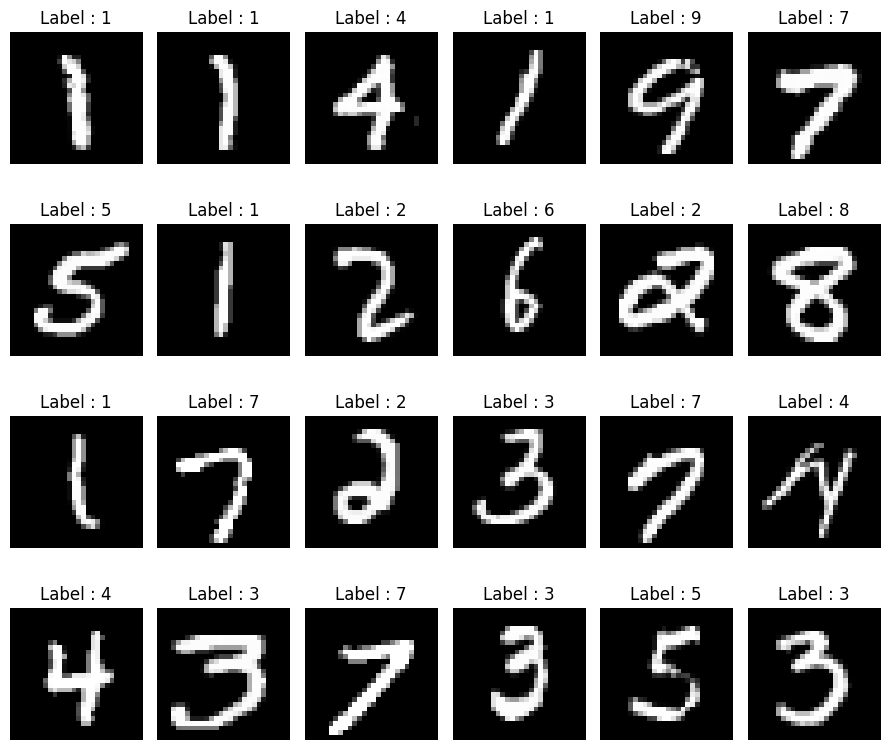

In [3]:
n_row = 4
n_col = 6
n = n_row * n_col

images = X_train[:n]
labels = y_train[:n]

fig, axes = plt.subplots(n_row, n_col, figsize=(1.5 * n_col, 2 * n_row))
for i in range(n):
    ax = axes[i//n_col, i%n_col]
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f'Label : {labels[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

### 1.3. Normalisation

In [4]:
X_train_norm = X_train / 255
X_valid_norm = X_valid / 255
X_test_norm  = X_test  / 255

---
## 2. CNN
---

### 2.1. Architecture

In [5]:
dim_inputs  = (28, 28, 1)   # tenseurs en imput de taille 28x28 en niveaux de gris (1 canal en entrée)
dim_outputs = 10    # nb de neurones en sortie (de 0 à 9)

n_conv_1 = 8    # nb couches / filtres de convolution 1
n_conv_2 = 16

n_units_hl = 100

dropout_conv1 = 0.2
dropout_conv2 = 0.2
dropout_hl    = 0.2

model = models.Sequential(name='CNN')

model.add(layers.Input(shape=dim_inputs)) # le modèle récupère des tenseurs de taille dim_imputs
# /!\ pas de vectorisation comme en DNN

# boucle 1 : convolution + pooling
model.add(layers.Conv2D(filters=n_conv_1, kernel_size=(3, 3), activation='relu', name='Convolutive_1'))   # on ajoute une couche de convolution 2D (=image)
model.add(layers.Dropout(rate=dropout_conv1, name='Dropout_Convolution_1'))         # drop out : permet de fixer certains poids, pour éviter de calculer tous les poids  lors de la retropropagation
model.add(layers.MaxPooling2D(pool_size=(2,2), strides=2, name='Max_pooling_1'))    # max pooling

# boucle 2
model.add(layers.Conv2D(filters=n_conv_2, kernel_size=(3, 3), name='Convolutive_2', activation='relu'))
model.add(layers.Dropout(rate=dropout_conv2, name='Dropout_Convolution_2'))
model.add(layers.MaxPooling2D(pool_size=(2,2), strides=2, name='Max_pooling_2'))

# fin de processus : on vectorise
model.add(layers.Flatten())

# DNN final
model.add(layers.Dense(units=n_units_hl, activation='relu', name='Hidden_layer'))
model.add(layers.Dropout(rate=dropout_hl, name='Dropout_Hidden_layer'))

# couche de sortie
model.add(layers.Dense(units=dim_outputs, activation='softmax'))

model.summary()

# interprétation summary
# convolutive_1 :
#     on passe d'images de taille 28,28,1 (28x28 sur un canal de niveaux de gris)
#     à des images de taille 26x26 (bordure en moins) sur 8 canaux
#     nb de paramètres : [3x3 (taille du noyau) + 1 (constante) = 10)] x 8 cuches de convolution
# drop out
# max pooling_1 :
#     on passe à des images de taille 13x13 sur 8 filtres/canaux
#     max pooling s'applique sur chaque canal => donc toujours 8
#     mais on divise la taille des imags par 2
# convolutive_2 :
#     on passe d'images de taille 13,13,81 (13x13 sur 8 canaux de convolution)
#     à des images de taille 11x11 (bordure en moins) sur 16 canaux
#     nb de paramètres : [3x3 (taille du noyau)x 8 (noyaux par filtre de convolution du départ) + 1 (constante)] x 16 couches de convolution = 1168
# drop out
# max pooling_1 :
#     on passe à des images de taille 5x5 sur 16 filtres/canaux

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Convolutive_1 (Conv2D)          │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Convolution_1 (Dropout) │ (None, 26, 26, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_pooling_1 (MaxPooling2D)    │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Convolutive_2 (Conv2D)          │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Convolution_2 (Dropout) │ (None, 11, 11, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_pooling_2 (MaxPooling2D)    │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_layer (Dense)            │ (None, 100)            │        40,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Hidden_layer (Dropout)  │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,358 (165.46 KB)

 Trainable params: 42,358 (165.46 KB)

 Non-trainable params: 0 (0.00 B)

### 2.2. Optimiseur

In [6]:
model.compile(optimizer = 'adam',
              loss      = 'sparse_categorical_crossentropy',
              metrics   = ['accuracy'])

callback = callbacks.EarlyStopping(monitor              = 'val_loss',
                                   mode                 = 'min',
                                   patience             = 5,
                                   restore_best_weights = True)

### 2.3. Entraînement

In [7]:
hist = model.fit(X_train_norm,
                 y_train,
                 batch_size      = 300,
                 epochs          = 50,
                 validation_data = (X_valid_norm, y_valid),
                 callbacks       = [callback],
                 verbose         = 1)

Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.7952 - loss: 0.6914 - val_accuracy: 0.9465 - val_loss: 0.2282
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9464 - loss: 0.1759 - val_accuracy: 0.9692 - val_loss: 0.1355
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9617 - loss: 0.1266 - val_accuracy: 0.9733 - val_loss: 0.1037
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9696 - loss: 0.0997 - val_accuracy: 0.9792 - val_loss: 0.0858
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9725 - loss: 0.0883 - val_accuracy: 0.9808 - val_loss: 0.0788
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9759 - loss: 0.0775 - val_accuracy: 0.9830 - val_loss: 0.0697
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9782 - loss: 0.0711 - val_accuracy: 0.9842 - val_loss: 0.0605
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9792 - loss: 0.0655 - val_accuracy: 

### 2.4. Prévisions

In [8]:
y_test_pred = model.predict(X_test_norm)
y_test_pred[0:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[1.41880676e-07, 4.99295254e-07, 3.41140803e-05, 3.29419066e-07,
        9.66975833e-08, 1.09528930e-09, 3.01936913e-11, 9.99962449e-01,
        4.13376426e-07, 2.01018224e-06],
       [8.78811832e-08, 1.41014425e-05, 9.99984622e-01, 5.61920537e-08,
        1.96201444e-10, 1.44991256e-12, 1.19729839e-06, 2.70525435e-10,
        1.16942136e-08, 3.77576388e-13],
       [6.05319826e-07, 9.99778628e-01, 1.77193160e-05, 1.22922783e-08,
        1.24643673e-04, 6.62139826e-07, 4.48758801e-05, 1.41741139e-05,
        1.83166376e-05, 1.09574920e-07],
       [9.99991417e-01, 7.10870807e-10, 3.94665491e-08, 1.40286749e-09,
        3.95718445e-08, 1.88568649e-07, 5.20982348e-06, 7.71593776e-08,
        7.92763757e-08, 2.90648086e-06],
       [5.25128939e-07, 2.56867203e-08, 2.64623651e-07, 1.83783513e-08,
        9.98263299e-01, 1.28263640e-08, 1.67684007e-07, 4.01876491e-07,
        4.24671249e-08, 1.73538830e-03]], dtype=float32)

In [9]:
y_test_pred_classes = np.argmax(y_test_pred, axis=1)
y_test_pred_classes[0:5]

array([7, 2, 1, 0, 4])

In [10]:
score_test = model.evaluate(X_test_norm, y_test, verbose=0)
print(f'Entropie test   : {score_test[0]:4.4f}')
print(f'Exactitude test : {score_test[1]:4.4f}')

Entropie test   : 0.0260
Exactitude test : 0.9908
